In [1]:
# Librerías con Pandas::
import pandas as pd # Para trabajar con DataFrames
import numpy as np # Para trabajar con arrays y funciones matemáticas

# Librerías para visualización de datos:
import matplotlib.pyplot as plt # Para crear gráficos personalizados
import seaborn as sns # Para crear gráficos más atractivos y con menos código **

# Configuraciones:
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame
import warnings # Para controlar las advertencias
warnings.filterwarnings('ignore', category=FutureWarning) # Para ignorar las advertencias de tipo FutureWarning

In [2]:
df = pd.read_csv("files/world_data_full_apply_nulos.csv", index_col=0) # Cargar el DataFrame desde un archivo CSV

df.head(2) # Mostrar las primeras filas del DataFrame para verificar que se ha cargado correctamente

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe


# 1. Relación entre fertilidad y esperanza de vida

- Variables:
    - fertility_rate
    - life_expectancy

In [3]:
# 1. Calcula el coeficiente de correlación de Pearson entre fertility_rate y life_expectancy.

In [4]:
corr = df["fertility_rate"].corr(df["life_expectancy"])

In [5]:
print(corr) 

#Aqui podemos ver, que el resultado es -0.84, al estar cerca del -1 podemos establecer que es una relación fuerte negativa.

-0.849152810736001


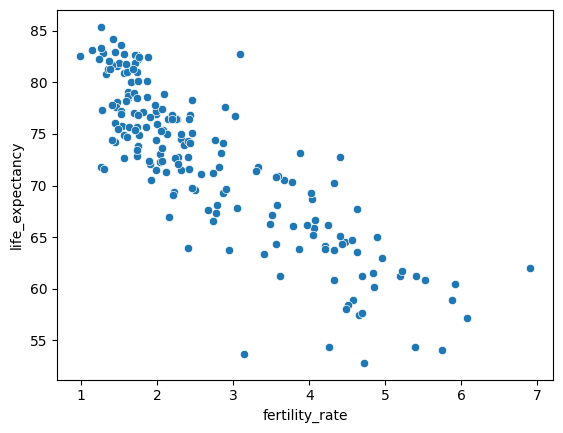

In [6]:
#2. Crea un diagrama de dispersión (scatter plot) con: Eje X: fertility_rate   Eje Y: life_expectancy

sns.scatterplot(data=df,x="fertility_rate",y="life_expectancy");

# Interpreta:

    - ¿La correlación es positiva o negativa?  Es negativa ¿Es fuerte, moderada o débil? Es fuerte.

    Describe, en lenguaje de negocio, qué significa esta relación:
        En general, las personas cuanto más edad, esperanza de vida, menos fértil es.

# 2. PIB, emisiones y población: ¿qué se relaciona con qué?

Variables:

    gdp
    co2-emissions
    population

In [7]:
df.head(1)

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.23,323.0,32.49,93.0,Kabul,8.672,149.9,2.3,AFN,4.47,2.1,0.7,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.93911,67.709953,Asia


# Para hacerlo, nos hemos basado en este ejercicio:

import pandas as pd

# Crear un DataFrame con datos de ejemplo
data = {
    "temperatura": [20, 25, 30, 35, 40],
    "ventas_helados": [200, 250, 300, 350, 400],
    "meloinvento": [2,2,4,5,5]
}
df = pd.DataFrame(data)

# Calcular la correlación
correlacion = df.corr()
print(correlacion)

In [8]:
df_p = df[["gdp","co2-emissions","population"]]

df_p.head(1)

,gdp,co2-emissions,population
0,1.910135e+10,8.672,NaN


In [9]:
# 1. Calcula una matriz de correlación solo con estas tres variables.

corr2 = df_p.corr()


In [10]:
corr2

,gdp,co2-emissions,population
gdp,1.000000,0.479662,0.274346
co2-emissions,0.479662,1.000000,-0.168062
population,0.274346,-0.168062,1.000000


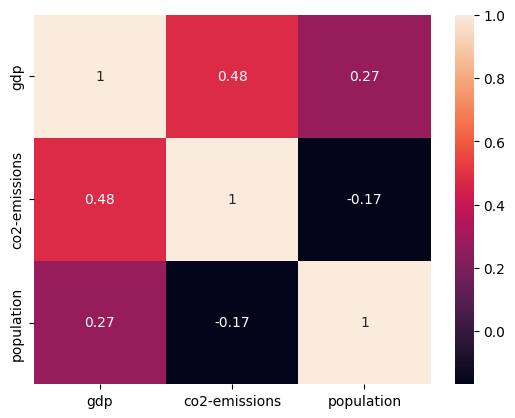

In [11]:
# 2. (Opcional) Representa la matriz en un heatmap.
sns.heatmap(corr2,annot=True); #para el heatmap no usamos el df, la correlación

# 3. Distribución de países por continente (variable categórica)

- Variable categórica: continent

In [12]:
#Calcula la tabla de frecuencias de continent:    Frecuencia absoluta (número de países por continente).,  Frecuencia relativa o porcentaje sobre el total.

df["continent"].value_counts(dropna=False).reset_index() #frecuencia absoluta

,continent,count
0,Africa,53
1,Europe,47
2,Asia,45
3,Central America,20
4,Oceania,14
5,South America,13
6,North America,2
7,NaN,1


In [13]:
round(df["continent"].value_counts(normalize=True,dropna=False).reset_index(),2) #frecuencia relativa

,continent,proportion
0,Africa,0.27
1,Europe,0.24
2,Asia,0.23
3,Central America,0.10
4,Oceania,0.07
5,South America,0.07
6,North America,0.01
7,NaN,0.01


In [14]:
df.head(2)

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe


# Interpreta:

        - ¿Qué continente tiene más países en el dataset? África, con un total de 53 países suponiendo un 27% sobre el total.

        - ¿Qué continentes están menos representados? Norte América con 2 países suponiendo un 1%.

        - Desde el punto de vista de un analista, ¿por qué es importante conocer esta distribución antes de comparar indicadores entre continentes?
            Es importante conocer esta distribución ya que los indicadores, por ejemplo el gpd, depende de la población.



# 4. Idioma oficial: ¿qué idiomas son más frecuentes?

Variable categórica: official_language

In [15]:
# 1. Calcula la frecuencia absoluta y relativa de official_language.

df["official_language"].value_counts(dropna=False).reset_index() #frecuencia absoluta

,official_language,count
0,English,31
1,French,25
2,Spanish,19
3,Arabic,18
4,Portuguese,7
...,...,...
72,Tuvaluan Language,1
73,Ukrainian,1
74,Uzbek,1
75,Vietnamese,1


In [16]:
round(df["official_language"].value_counts(normalize=True,dropna=False).reset_index(),2) #frecuencia relativa

,official_language,proportion
0,English,0.16
1,French,0.13
2,Spanish,0.10
3,Arabic,0.09
4,Portuguese,0.04
...,...,...
72,Tuvaluan Language,0.01
73,Ukrainian,0.01
74,Uzbek,0.01
75,Vietnamese,0.01


In [17]:
# Identifica:   Los 5 idiomas oficiales más frecuentes.

round(df["official_language"].value_counts(normalize=True,dropna=False).reset_index(),2).head(5) #frecuencia relativa

,official_language,proportion
0,English,0.16
1,French,0.13
2,Spanish,0.10
3,Arabic,0.09
4,Portuguese,0.04


# Interpreta:

    - ¿Hay algún idioma claramente dominante? A nivel de frecuencia relativa en su total, NO, partiendo de los cuatro primeros, hay una diferencia mínima entre ellos.

    - ¿Qué implicaciones podría tener esto a la hora de diseñar encuestas, campañas o informes internacionales?
        Esto implica que, para llegar a la mayoría de las personas, sería enfocarla a los idiomas más predominantes (inglés, español, francés, árabe.)
        

# 5. Continente vs. nivel de ingresos

En esta base de datos tenemos gdp (Producto Interno Bruto per cápita aproximado). Crea primero una variable categórica derivada a partir de gdp, por ejemplo:

    - bajo: países con gdp por debajo del percentil 33.

    - medio: entre los percentiles 33 y 66.

    - alto: por encima del percentil 66.

Puedes llamarla, por ejemplo, gdp_level.

In [31]:
#1. Crea la nueva columna gdp_level en el DataFrame.
pbajo = np.nanpercentile(df["gdp"],33).round(2)
palto =np.nanpercentile(df["gdp"],66).round(2)

print (pbajo,palto)
bajo = df[df["gdp"] < pbajo]
bajo.head(2)

13737619474.36 88117734745.76


,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
3,Andorra,164.0,AD,40.0,468.0,NaN,7.20,376.0,Andorra la Vella,469.0,NaN,NaN,EUR,1.27,34.0,1.51,3.154058e+09,106.4,NaN,2.7,Andorra la Vella,NaN,NaN,6.63,Catalan,36.4,3.33,77.142,NaN,NaN,NaN,NaN,67.873,42.506285,1.521801,Europe
5,Antigua and Barbuda,223.0,AG,20.5,443.0,0.0,15.33,1.0,"St. John's, Saint John",557.0,113.81,1.2,XCD,1.99,22.3,0.99,1.727759e+09,105.0,24.8,5.0,"St. John's, Saint John",76.9,42.0,3.04,English,24.3,2.76,97.118,NaN,16.5,43.0,NaN,23.800,17.060816,-61.796428,Central America


In [30]:
medio = df[(df["gdp"] >= pbajo) & (df["gdp"] <= palto)]
medio.head(2)

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe


In [32]:
alto = df[df["gdp"] > palto]
alto.head(2)

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
2,Algeria,18.0,DZ,17.4,NaN,317.0,24.28,213.0,Algiers,150.006,151.36,2.0,DZD,3.02,0.8,0.28,1.699882e+11,109.9,51.4,20.1,Algiers,76.7,112.0,0.95,Arabic,28.1,1.72,NaN,41.2,37.2,66.1,11.70,NaN,28.033886,1.659626,Africa
4,Angola,26.0,AO,47.5,NaN,117.0,40.73,244.0,Luanda,34.693,261.73,17.1,AOA,5.52,46.3,0.97,9.463542e+10,113.5,9.3,51.6,Luanda,60.8,241.0,0.71,Portuguese,33.4,0.21,NaN,77.5,9.2,49.1,6.89,NaN,-11.202692,17.873887,Africa
